In [1]:
%%capture
!pip install -q transformers accelerate bitsandbytes
!pip install -q peft trl
!pip install -q datasets
!pip install -q huggingface_hub
!pip install -q rouge-score nltk
!pip install -q pandas matplotlib seaborn
!pip install -q sentencepiece protobuf

print("All dependencies installed!")

In [3]:
import os
import json
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    pipeline,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    PeftModel,
    TaskType,
)
from trl import SFTTrainer, SFTConfig
from datasets import Dataset, DatasetDict

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

from rouge_score import rouge_scorer

warnings.filterwarnings("ignore")

# ── Device Info ──
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

    # FIXED LINE (total_mem -> total_memory)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"Total VRAM: {vram:.1f} GB")

    # EXTRA (useful for debugging)
    allocated = torch.cuda.memory_allocated(0) / 1e9
    reserved = torch.cuda.memory_reserved(0) / 1e9

    print(f"Allocated VRAM: {allocated:.2f} GB")
    print(f"Reserved VRAM: {reserved:.2f} GB")

Device: cuda
GPU: Tesla T4
Total VRAM: 15.6 GB
Allocated VRAM: 0.00 GB
Reserved VRAM: 0.00 GB


In [4]:
# ──────────────────────────────────────────────────────────
# We create a synthetic AI/ML research QA dataset.
# In practice, you can also load from CSV, JSON, or HF Hub.
# ──────────────────────────────────────────────────────────

qa_dataset_raw = [
    # ── Transformers & Attention ──
    {"input": "What is the Transformer architecture?",
     "output": "The Transformer is a neural network architecture introduced by Vaswani et al. in 2017. It relies entirely on self-attention mechanisms, dispensing with recurrence and convolutions. It uses an encoder-decoder structure with multi-head attention, positional encodings, and feed-forward networks."},
    {"input": "Explain multi-head attention in Transformers.",
     "output": "Multi-head attention runs multiple attention functions in parallel. The queries, keys, and values are linearly projected h times with different learned projections. Each head attends to different representation subspaces. The outputs are concatenated and projected to produce the final result."},
    {"input": "What are positional encodings and why are they needed?",
     "output": "Positional encodings inject information about token positions into the model since Transformers have no recurrence or convolution. The original paper uses sine and cosine functions of different frequencies. Without positional encodings, the model cannot distinguish between different orderings of the same tokens."},
    {"input": "What is self-attention?",
     "output": "Self-attention is a mechanism where each position in a sequence attends to all positions in the same sequence. It computes attention weights using queries, keys, and values derived from the input. The output is a weighted sum of values, where weights are determined by the compatibility of queries and keys."},
    {"input": "How does the encoder-decoder structure work in Transformers?",
     "output": "The encoder processes the input sequence and produces continuous representations. The decoder generates the output sequence one token at a time, attending to both the encoder output (cross-attention) and previously generated tokens (masked self-attention). Both consist of stacked layers with attention and feed-forward sublayers."},

    # ── BERT ──
    {"input": "What is BERT and how does it work?",
     "output": "BERT (Bidirectional Encoder Representations from Transformers) is a pre-trained language model by Devlin et al. (2019). It uses masked language modeling (MLM) to pre-train deep bidirectional representations by jointly conditioning on both left and right context. It also uses next sentence prediction (NSP) as a secondary objective."},
    {"input": "What is masked language modeling in BERT?",
     "output": "Masked Language Modeling (MLM) randomly masks 15% of input tokens and trains the model to predict them. Of the masked tokens, 80% are replaced with [MASK], 10% with a random token, and 10% remain unchanged. This allows bidirectional pre-training unlike autoregressive models."},
    {"input": "How does BERT fine-tuning work?",
     "output": "BERT fine-tuning initializes a model with pre-trained weights and trains all parameters on labeled downstream task data. A task-specific output layer is added on top. Each task gets its own fine-tuned model. Fine-tuning is relatively inexpensive compared to pre-training."},
    {"input": "What is the difference between BERT_BASE and BERT_LARGE?",
     "output": "BERT_BASE has 12 layers, 768 hidden dimensions, 12 attention heads, and 110M parameters. BERT_LARGE has 24 layers, 1024 hidden dimensions, 16 attention heads, and 340M parameters. BERT_LARGE generally achieves better performance but requires more compute."},
    {"input": "What is next sentence prediction in BERT?",
     "output": "Next Sentence Prediction (NSP) is a binary classification task where the model predicts whether sentence B follows sentence A in the original text. 50% of training examples are actual consecutive sentences and 50% are random pairs. NSP helps the model understand sentence relationships."},

    # ── GPT ──
    {"input": "What is GPT-3 and how big is it?",
     "output": "GPT-3 is an autoregressive language model with 175 billion parameters developed by OpenAI (Brown et al., 2020). It is 10x larger than any previous non-sparse language model. GPT-3 demonstrates strong few-shot learning capabilities without any gradient updates or fine-tuning."},
    {"input": "Explain few-shot learning in the context of GPT-3.",
     "output": "Few-shot learning in GPT-3 involves providing K examples of a task at inference time as conditioning in the prompt, without any gradient updates. K is typically 10-100 examples. Zero-shot uses no examples, one-shot uses one example. Performance generally improves with more examples."},
    {"input": "What data was GPT-3 trained on?",
     "output": "GPT-3 was trained on about 499 billion tokens from: filtered Common Crawl (410B tokens), WebText2 (19B), Books1 (12B), Books2 (55B), and Wikipedia (3B). The training data was weighted so higher-quality sources were sampled more frequently."},
    {"input": "What is in-context learning?",
     "output": "In-context learning is a capability of large language models where they perform tasks by conditioning on examples provided in the prompt, without any parameter updates. The model uses the pattern in the examples to generate appropriate responses for new inputs. This emerged as a key capability of GPT-3."},
    {"input": "What are the limitations of GPT-3?",
     "output": "GPT-3 has several limitations: poor performance on natural language inference tasks, difficulty comparing two text snippets, inconsistent reasoning on complex tasks, potential for generating biased or harmful content, high computational cost, and inability to learn from interactions after training."},

    # ── RAG ──
    {"input": "What is Retrieval-Augmented Generation (RAG)?",
     "output": "RAG combines pre-trained parametric memory (language model) with non-parametric memory (document retrieval). It retrieves relevant documents from an external corpus and conditions generation on both the input and retrieved passages. This grounds generation in factual evidence and reduces hallucination."},
    {"input": "What are the components of a RAG system?",
     "output": "A RAG system has two main components: a retriever and a generator. The retriever (e.g., DPR with FAISS) finds relevant passages from a knowledge source. The generator (e.g., BART or an LLM) conditions on both the input query and retrieved passages to produce the output."},
    {"input": "What is the difference between RAG-Sequence and RAG-Token?",
     "output": "RAG-Sequence uses the same retrieved document to generate the complete output sequence. RAG-Token can use different retrieved documents for different output tokens, providing more flexibility. RAG-Token allows the model to synthesize information from multiple sources within a single output."},
    {"input": "What are the advantages of RAG over pure generative models?",
     "output": "RAG offers several advantages: the knowledge source can be updated without retraining, it provides provenance for answers by citing source documents, it reduces hallucination by grounding in evidence, and it can handle knowledge that wasn't in the training data."},
    {"input": "How does the retriever work in RAG?",
     "output": "The retriever uses a bi-encoder architecture where queries and documents are encoded independently. A BERT-based query encoder creates query representations. Documents are pre-encoded and stored in a FAISS index. At inference, the query embedding is used for Maximum Inner Product Search to find relevant passages."},

    # ── LoRA & Fine-tuning ──
    {"input": "What is LoRA and how does it work?",
     "output": "LoRA (Low-Rank Adaptation) freezes pre-trained model weights and injects trainable low-rank decomposition matrices (A and B) into Transformer layers. The weight update is ΔW = BA, where A and B have much fewer parameters than W. This reduces trainable parameters by up to 10,000x while maintaining performance."},
    {"input": "What is QLoRA?",
     "output": "QLoRA (Quantized LoRA) extends LoRA by quantizing the base model to 4-bit precision (using NF4 data type) while training LoRA adapters in higher precision. This enables fine-tuning of very large models (65B+) on a single GPU while achieving performance comparable to full 16-bit fine-tuning."},
    {"input": "How does LoRA rank affect performance?",
     "output": "The rank r controls LoRA's expressiveness. Surprisingly, even very small ranks (r=1 or r=2) often suffice. Increasing rank beyond 4-8 provides diminishing returns. This suggests weight updates during task adaptation have a very low intrinsic rank. Higher ranks use more parameters and memory."},
    {"input": "What are the advantages of LoRA over full fine-tuning?",
     "output": "LoRA reduces trainable parameters by up to 10,000x and GPU memory by 3x. It adds no inference latency since adapter weights merge with pre-trained weights. Multiple task-specific adaptations can share the same base model. Training is faster and storage is more efficient."},
    {"input": "What is PEFT in the context of LLM fine-tuning?",
     "output": "PEFT (Parameter-Efficient Fine-Tuning) is a family of methods that fine-tune only a small subset of model parameters while keeping most pre-trained weights frozen. Methods include LoRA, prefix-tuning, prompt-tuning, and adapters. PEFT significantly reduces compute and memory requirements for adaptation."},

    # ── Training Concepts ──
    {"input": "What is transfer learning in NLP?",
     "output": "Transfer learning in NLP involves pre-training a model on large general-purpose text data, then adapting it to specific downstream tasks through fine-tuning. The pre-trained model captures general language understanding, which transfers to various tasks. This approach dramatically improves performance compared to training from scratch."},
    {"input": "What is gradient accumulation in training?",
     "output": "Gradient accumulation is a technique where gradients are accumulated over multiple mini-batches before performing a weight update. This simulates a larger effective batch size without requiring additional GPU memory. For example, accumulating over 4 steps with batch size 4 simulates batch size 16."},
    {"input": "What is mixed precision training?",
     "output": "Mixed precision training uses both FP16 and FP32 formats. Forward and backward passes use FP16 for speed and memory efficiency, while the master copy of weights and loss scaling use FP32 for numerical stability. This typically provides 2x speedup with minimal accuracy loss."},
    {"input": "What is the purpose of a learning rate scheduler?",
     "output": "A learning rate scheduler adjusts the learning rate during training. Common strategies include cosine annealing, linear warmup followed by decay, and step-based schedules. Warmup helps stabilize early training, while decay helps the model converge to a better minimum. Proper scheduling significantly impacts final model quality."},
    {"input": "What is the difference between pre-training and fine-tuning?",
     "output": "Pre-training learns general language representations from large unlabeled datasets using self-supervised objectives like MLM or next-token prediction. Fine-tuning adapts pre-trained models to specific downstream tasks using smaller labeled datasets. Pre-training is expensive but done once; fine-tuning is relatively cheap and task-specific."},

    # ── Embeddings & Vector Search ──
    {"input": "What are text embeddings?",
     "output": "Text embeddings are dense vector representations of text in a continuous vector space. Similar texts have similar embeddings (close in vector space). Models like Sentence-BERT produce these embeddings. They are used for semantic search, clustering, and similarity comparison."},
    {"input": "What is cosine similarity and how is it used in NLP?",
     "output": "Cosine similarity measures the cosine of the angle between two vectors, ranging from -1 to 1. In NLP, it compares text embeddings: 1 means identical direction (most similar), 0 means orthogonal, -1 means opposite. It is preferred over Euclidean distance for high-dimensional spaces because it is invariant to vector magnitude."},
    {"input": "What is FAISS and what is it used for?",
     "output": "FAISS (Facebook AI Similarity Search) is a library for efficient similarity search and clustering of dense vectors. It supports various index types including flat (exact), IVF (approximate), and HNSW (graph-based). It is widely used in RAG systems for fast nearest-neighbor retrieval over millions of vectors."},
    {"input": "What is a vector database?",
     "output": "A vector database stores and retrieves high-dimensional vector embeddings. Unlike traditional databases that use exact matching, vector databases perform similarity search using metrics like cosine similarity or inner product. Examples include ChromaDB, FAISS, Pinecone, Weaviate, and Milvus."},
    {"input": "What is semantic search?",
     "output": "Semantic search finds documents based on meaning rather than keyword matching. It converts queries and documents into dense vector embeddings and retrieves the most similar vectors. This captures synonyms, paraphrases, and conceptual relationships that keyword search misses."},

    # ── Evaluation Metrics ──
    {"input": "What is BLEU score?",
     "output": "BLEU (Bilingual Evaluation Understudy) measures the overlap of n-grams between generated text and reference text. It computes precision for n-grams of different lengths (usually 1-4) and applies a brevity penalty. BLEU ranges from 0 to 1, with higher values indicating closer match to the reference."},
    {"input": "What is ROUGE score?",
     "output": "ROUGE (Recall-Oriented Understudy for Gisting Evaluation) measures overlap between generated and reference text focusing on recall. ROUGE-1 measures unigram overlap, ROUGE-2 measures bigram overlap, and ROUGE-L measures the longest common subsequence. Each has precision, recall, and F1 variants."},
    {"input": "What is perplexity in language modeling?",
     "output": "Perplexity measures how well a language model predicts text. It is the exponential of the average negative log-likelihood per token. Lower perplexity means better prediction. A perplexity of k means the model is as uncertain as choosing uniformly among k options at each step."},
    {"input": "How do you evaluate a fine-tuned language model?",
     "output": "Evaluation methods include: automated metrics (BLEU, ROUGE, perplexity), task-specific metrics (accuracy, F1 for classification), human evaluation (fluency, relevance, correctness), and comparison with the base model. A comprehensive evaluation uses multiple metrics and compares base vs fine-tuned performance."},
    {"input": "What is the difference between intrinsic and extrinsic evaluation?",
     "output": "Intrinsic evaluation measures model quality on its own terms (e.g., perplexity, BLEU). Extrinsic evaluation measures how the model performs on a downstream application (e.g., question answering accuracy). Both are important: intrinsic metrics are easier to compute, but extrinsic metrics measure real-world utility."},

    # ── Model Architectures ──
    {"input": "What is the difference between encoder-only, decoder-only, and encoder-decoder models?",
     "output": "Encoder-only models (BERT) process the full input bidirectionally and are good for understanding tasks (classification, NER). Decoder-only models (GPT) generate text autoregressively and excel at generation. Encoder-decoder models (T5, BART) first encode the input then decode the output, suitable for translation and summarization."},
    {"input": "What is the attention mechanism?",
     "output": "The attention mechanism allows a model to focus on relevant parts of the input when producing each output element. It computes compatibility scores between a query and set of key-value pairs. The output is a weighted sum of values, where weights come from softmax of query-key dot products scaled by the square root of dimension."},
    {"input": "What are autoregressive language models?",
     "output": "Autoregressive language models generate text one token at a time, where each token is conditioned on all previous tokens. The model learns P(x_t | x_1, ..., x_{t-1}). Examples include GPT, LLaMA, and Mistral. They excel at text generation but cannot condition on future context during generation."},
    {"input": "What is the role of the feed-forward network in Transformers?",
     "output": "The feed-forward network (FFN) in Transformers processes each position independently after attention. It typically consists of two linear transformations with a ReLU or GELU activation in between. The FFN expands the representation dimension (often 4x), applies non-linearity, then projects back. It stores factual knowledge learned during training."},
    {"input": "What is layer normalization?",
     "output": "Layer normalization normalizes activations across the feature dimension within each sample, independent of other samples in the batch. In Transformers, it is applied before (pre-norm) or after (post-norm) each sublayer. Pre-norm makes training more stable for very deep models. It helps with gradient flow and training stability."},

    # ── Tokenization ──
    {"input": "What is tokenization in NLP?",
     "output": "Tokenization is the process of converting raw text into a sequence of tokens that the model can process. Methods include word-level, character-level, and subword tokenization. Modern LLMs use subword methods like BPE, WordPiece, or SentencePiece that balance vocabulary size with the ability to handle unseen words."},
    {"input": "What is Byte Pair Encoding (BPE)?",
     "output": "BPE is a subword tokenization algorithm that starts with individual characters and iteratively merges the most frequent adjacent pairs. This creates a vocabulary of common subword units. BPE handles rare and unseen words by decomposing them into known subword pieces. GPT models use BPE."},
    {"input": "What is the difference between BPE and WordPiece?",
     "output": "BPE merges the most frequent adjacent token pairs, while WordPiece merges pairs that maximize the likelihood of the training data. BPE is used by GPT models, while WordPiece is used by BERT. Both produce subword vocabularies but differ in their merge criteria."},

    # ── Scaling & Efficiency ──
    {"input": "What are scaling laws in language models?",
     "output": "Scaling laws describe how model performance improves predictably as a power law with model size, dataset size, and compute. Larger models trained on more data consistently achieve lower loss. The Chinchilla paper showed optimal compute allocation requires scaling model size and data proportionally."},
    {"input": "What is model distillation?",
     "output": "Model distillation (knowledge distillation) trains a smaller student model to mimic a larger teacher model. The student learns from the teacher's soft output probabilities rather than hard labels. This produces smaller, faster models that retain much of the teacher's performance. Examples include DistilBERT and TinyBERT."},
    {"input": "What is quantization in the context of neural networks?",
     "output": "Quantization reduces the precision of model weights from higher formats (FP32, FP16) to lower formats (INT8, INT4). This reduces memory usage and increases inference speed. Post-training quantization is applied after training; quantization-aware training incorporates quantization during training for better accuracy."},
    {"input": "What is the NF4 data type used in QLoRA?",
     "output": "NF4 (4-bit NormalFloat) is a quantization format designed for QLoRA. It quantizes weights to 4 bits using a data type optimized for normally distributed values. Combined with double quantization (quantizing the quantization constants), NF4 achieves near lossless 4-bit quantization of pre-trained models."},
]

# ── Expand the dataset with augmented variations ──
augmented = []
augmentation_prefixes = [
    "Can you explain ",
    "Tell me about ",
    "What do you know about ",
    "Please describe ",
    "I'd like to understand ",
    "Help me learn about ",
    "Could you clarify ",
    "Briefly explain ",
]

for item in qa_dataset_raw:
    augmented.append(item)
    # Create augmented versions
    for prefix in random.sample(augmentation_prefixes, min(3, len(augmentation_prefixes))):
        # Extract the topic from the question
        topic = item["input"].lower()
        topic = topic.replace("what is ", "").replace("what are ", "")
        topic = topic.replace("how does ", "").replace("how do ", "")
        topic = topic.replace("explain ", "").replace("?", "").strip()

        new_q = f"{prefix}{topic}?"
        augmented.append({
            "input": new_q,
            "output": item["output"],
        })

# Shuffle
random.seed(42)
random.shuffle(augmented)

print(f" Dataset Statistics:")
print(f"   Original examples: {len(qa_dataset_raw)}")
print(f"   After augmentation: {len(augmented)}")
print(f"   Sample:")
for i in range(3):
    print(f"   [{i}] Q: {augmented[i]['input'][:80]}")
    print(f"       A: {augmented[i]['output'][:80]}...")

 Dataset Statistics:
   Original examples: 52
   After augmentation: 208
   Sample:
   [0] Q: Briefly explain next sentence prediction in bert?
       A: Next Sentence Prediction (NSP) is a binary classification task where the model p...
   [1] Q: Help me learn about the advantages of lora over full fine-tuning?
       A: LoRA reduces trainable parameters by up to 10,000x and GPU memory by 3x. It adds...
   [2] Q: Help me learn about you evaluate a fine-tuned language model?
       A: Evaluation methods include: automated metrics (BLEU, ROUGE, perplexity), task-sp...


In [5]:
# ──────────────────────────────────────────────────────────
# Format data into the chat/instruction template
# ──────────────────────────────────────────────────────────

SYSTEM_MSG = "You are an AI research assistant specializing in machine learning, deep learning, and natural language processing. Provide clear, accurate, and detailed answers."

def format_chat(example: dict) -> str:
    """Format as a standard instruction-response pair."""
    text = f"""### System:
{SYSTEM_MSG}

### User:
{example['input']}

### Assistant:
{example['output']}"""
    return text

# Create formatted texts
formatted_data = []
for item in augmented:
    formatted_data.append({
        "input": item["input"],
        "output": item["output"],
        "text": format_chat(item),
    })

# Train/test split (90/10)
split_idx = int(len(formatted_data) * 0.9)
train_data = formatted_data[:split_idx]
eval_data  = formatted_data[split_idx:]

train_dataset = Dataset.from_list(train_data)
eval_dataset  = Dataset.from_list(eval_data)

print(f" Dataset split:")
print(f"   Train: {len(train_dataset)} examples")
print(f"   Eval:  {len(eval_dataset)} examples")
print(f"\n── Sample formatted text ──")
print(train_dataset[0]["text"][:500])

 Dataset split:
   Train: 187 examples
   Eval:  21 examples

── Sample formatted text ──
### System:
You are an AI research assistant specializing in machine learning, deep learning, and natural language processing. Provide clear, accurate, and detailed answers.

### User:
Briefly explain next sentence prediction in bert?

### Assistant:
Next Sentence Prediction (NSP) is a binary classification task where the model predicts whether sentence B follows sentence A in the original text. 50% of training examples are actual consecutive sentences and 50% are random pairs. NSP helps the mod


In [6]:
# Save dataset for documentation / reproducibility
os.makedirs("/content/dataset", exist_ok=True)

# Save as JSON
with open("/content/dataset/train.json", "w") as f:
    json.dump(train_data, f, indent=2)
with open("/content/dataset/eval.json", "w") as f:
    json.dump(eval_data, f, indent=2)

# Save as CSV
pd.DataFrame(train_data).to_csv("/content/dataset/train.csv", index=False)
pd.DataFrame(eval_data).to_csv("/content/dataset/eval.csv", index=False)

print(" Dataset saved to /content/dataset/")
print(f"   train.json: {len(train_data)} examples")
print(f"   eval.json:  {len(eval_data)} examples")

 Dataset saved to /content/dataset/
   train.json: 187 examples
   eval.json:  21 examples


In [8]:
# ──────────────────────────────────────────────────────────
# Model selection — all ungated, no access request needed!
# ──────────────────────────────────────────────────────────
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

print(f"Loading model: {MODEL_ID}")

# 4-bit quantization config (QLoRA)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Load model (FIX: torch_dtype → dtype)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.float16,
)

# Disable cache for training
model.config.use_cache = False

print(f"Model loaded: {MODEL_ID}")
print(f"Parameters: {model.num_parameters():,}")

# SAFE device map print
device_map = getattr(model, "hf_device_map", None)
if device_map is not None:
    print(f"Device map: {device_map}")
else:
    print("Device map not available (handled automatically)")

Loading model: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model loaded: Qwen/Qwen2.5-1.5B-Instruct
Parameters: 1,543,714,304
Device map not available (handled automatically)


In [9]:
# ──────────────────────────────────────────────────────────
# Generate answers with the BASE model for comparison
# ──────────────────────────────────────────────────────────

base_pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=256,
    temperature=0.3,
    top_p=0.9,
    do_sample=True,
    repetition_penalty=1.2,
)

# Select evaluation questions
eval_questions = [item["input"] for item in eval_data[:20]]
eval_references = [item["output"] for item in eval_data[:20]]

print(" Generating base model responses...\n")
base_responses = []

for i, q in enumerate(eval_questions):
    prompt = f"""### System:
{SYSTEM_MSG}

### User:
{q}

### Assistant:
"""
    output = base_pipe(prompt, return_full_text=False)
    response = output[0]["generated_text"].strip()
    base_responses.append(response)

    if i < 3:  # Print first 3
        print(f"Q: {q}")
        print(f"A (base): {response[:200]}...")
        print("-" * 60)

print(f"\n Generated {len(base_responses)} base model responses")

Passing `generation_config` together with generation-related arguments=({'repetition_penalty', 'temperature', 'do_sample', 'top_p', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


 Generating base model responses...



Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Please describe the limitations of gpt-3?
A (base): GPT-3 is a large-scale transformer-based model that has been trained on vast amounts of text data from various sources to generate human-like responses for tasks such as translation, summarization, qu...
------------------------------------------------------------


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Please describe in-context learning?
A (base): In context learning refers to a type of artificial intelligence (AI) training method where the model is trained on data that includes information about its environment or task at hand. This approach c...
------------------------------------------------------------


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Can you explain bert and it work?
A (base): Sure! BERT (Bidirectional Encoder Representations from Transformers) is a state-of-the-art pre-trained model that has been widely used for tasks such as text classification, question answering, sentim...
------------------------------------------------------------


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both


 Generated 20 base model responses


In [10]:
# ──────────────────────────────────────────────────────────
# LoRA Configuration
# ──────────────────────────────────────────────────────────

# Prepare model for k-bit training
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,                          # Rank — try 4, 8, 16, 32
    lora_alpha=32,                 # Scaling factor
    lora_dropout=0.05,             # Dropout for regularization
    bias="none",                   # Don't train bias terms
    task_type=TaskType.CAUSAL_LM,  # Causal language modeling
    target_modules=[               # Which layers to adapt
        "q_proj", "k_proj", "v_proj", "o_proj",  # Attention
        "gate_proj", "up_proj", "down_proj",      # MLP
    ],
)

# Apply LoRA
model = get_peft_model(model, lora_config)

# Print trainable parameters
trainable, total = model.get_nb_trainable_parameters()
print(f" LoRA Configuration:")
print(f"   Rank (r):      {lora_config.r}")
print(f"   Alpha:         {lora_config.lora_alpha}")
print(f"   Dropout:       {lora_config.lora_dropout}")
print(f"   Target modules: {lora_config.target_modules}")
print(f"\n Parameters:")
print(f"   Total:     {total:>12,}")
print(f"   Trainable: {trainable:>12,} ({100 * trainable / total:.4f}%)")

 LoRA Configuration:
   Rank (r):      16
   Alpha:         32
   Dropout:       0.05
   Target modules: {'up_proj', 'down_proj', 'gate_proj', 'v_proj', 'o_proj', 'k_proj', 'q_proj'}

 Parameters:
   Total:     1,562,179,072
   Trainable:   18,464,768 (1.1820%)


In [13]:
OUTPUT_DIR = "/content/finetuned_model"

from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_steps=100,   #  FIXED (instead of warmup_ratio)
    lr_scheduler_type="cosine",
    fp16=True,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    dataset_text_field="text",
    packing=False,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer   #  correct for latest TRL
)

print("Training Configuration:")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Grad accum: {training_args.gradient_accumulation_steps}")
print(f"Effective batch: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"Learning rate: {training_args.learning_rate}")
print(f"Warmup steps: {training_args.warmup_steps}")
print(f"Scheduler: {training_args.lr_scheduler_type}")

Adding EOS to train dataset:   0%|          | 0/187 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/187 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/21 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/21 [00:00<?, ? examples/s]

Training Configuration:
Epochs: 3
Batch size: 4
Grad accum: 4
Effective batch: 16
Learning rate: 0.0002
Warmup steps: 100
Scheduler: SchedulerType.COSINE


In [31]:
# ══════════════════════════════════════════════════════════
# FINAL STABLE CODE (NO BF16 ERROR + PROPER TRAINING)
# ══════════════════════════════════════════════════════════

import torch
import time
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
from trl import SFTTrainer

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
OUTPUT_DIR = "/content/finetuned_model"

# ── Quantization Config ──
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# ── Tokenizer ──
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
tokenizer.model_max_length = 512

# ── Model ──
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto"
)

model.config.use_cache = False

# ── Prepare for QLoRA ──
model = prepare_model_for_kbit_training(model)

# ── LoRA ──
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
)

model = get_peft_model(model, lora_config)


model.print_trainable_parameters()

# ── Training Config ──
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    fp16=False,          #  AMP OFF (FINAL FIX)
    bf16=False,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    max_grad_norm=1.0,
)

# ── Formatting function ──
def formatting_func(example):
    return example["text"]

# ── Trainer ──
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=training_args,
    processing_class=tokenizer,
    formatting_func=formatting_func
)

# ── Train ──
print(" Starting fine-tuning...\n")

train_start = time.time()
train_result = trainer.train()
train_time = time.time() - train_start

print("\nTraining complete!")
print(f"Duration: {train_time / 60:.1f} minutes")
print(f"Final loss: {train_result.training_loss:.4f}")

# ── Save ──
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"\nModel saved at: {OUTPUT_DIR}")

# ── Logs ──
print("\nTraining Logs:")
for log in trainer.state.log_history:
    if "loss" in log:
        print(log)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


Applying formatting function to train dataset:   0%|          | 0/187 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/187 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/187 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/21 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


 Starting fine-tuning...



Step,Training Loss,Validation Loss



Training complete!
Duration: 2.6 minutes
Final loss: 2.1710

Model saved at: /content/finetuned_model

Training Logs:
{'loss': 2.623623275756836, 'grad_norm': 2.453125, 'learning_rate': 9e-06, 'entropy': 1.808130905032158, 'num_tokens': 17263.0, 'mean_token_accuracy': 0.49587695226073264, 'epoch': 0.851063829787234, 'step': 10}
{'loss': 2.2913623809814454, 'grad_norm': 1.921875, 'learning_rate': 1.9e-05, 'entropy': 1.863001172359173, 'num_tokens': 34123.0, 'mean_token_accuracy': 0.538155415119269, 'epoch': 1.6808510638297873, 'step': 20}
{'loss': 1.9236385345458984, 'grad_norm': 1.7734375, 'learning_rate': 2.9e-05, 'entropy': 1.7028080836320534, 'num_tokens': 50921.0, 'mean_token_accuracy': 0.6139768300912319, 'epoch': 2.5106382978723403, 'step': 30}


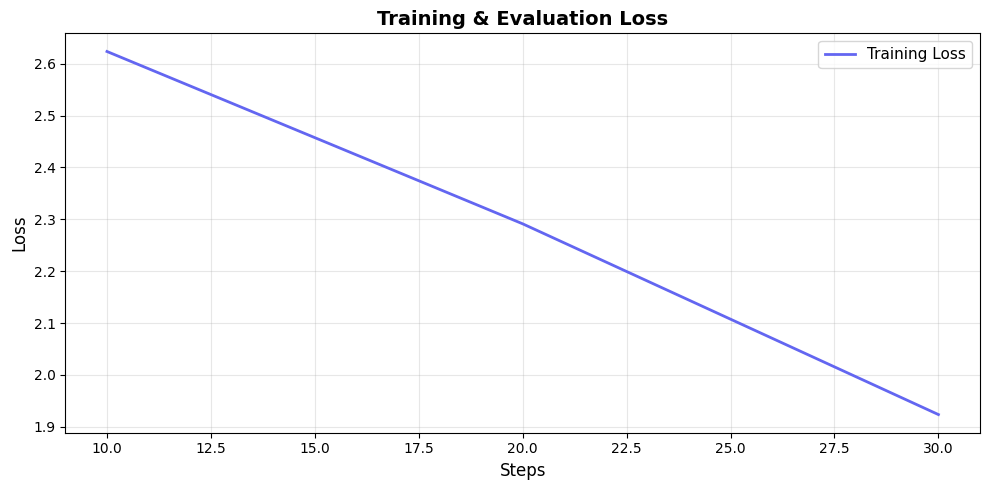

 Loss chart saved


In [32]:
log_history = trainer.state.log_history

train_losses = [(l["step"], l["loss"]) for l in log_history if "loss" in l]
eval_losses  = [(l["step"], l["eval_loss"]) for l in log_history if "eval_loss" in l]

fig, ax = plt.subplots(figsize=(10, 5))

if train_losses:
    steps, losses = zip(*train_losses)
    ax.plot(steps, losses, label="Training Loss", color="#6366f1", linewidth=2)

if eval_losses:
    steps, losses = zip(*eval_losses)
    ax.plot(steps, losses, label="Eval Loss", color="#f43f5e", linewidth=2, marker="o")

ax.set_xlabel("Steps", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Training & Evaluation Loss", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/training_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Loss chart saved")

In [33]:
ADAPTER_DIR = "/content/finetuned_adapter"
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f" LoRA adapter saved to {ADAPTER_DIR}")
print(f"   Files:", os.listdir(ADAPTER_DIR))

 LoRA adapter saved to /content/finetuned_adapter
   Files: ['adapter_config.json', 'README.md', 'adapter_model.safetensors', 'tokenizer.json', 'chat_template.jinja', 'tokenizer_config.json']


In [34]:
del model
del trainer
torch.cuda.empty_cache()

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)

ft_model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
ft_model.eval()

ft_pipe = pipeline(
    "text-generation",
    model=ft_model,
    tokenizer=tokenizer,
    max_new_tokens=256,
    temperature=0.3,
    top_p=0.9,
    do_sample=True,
    repetition_penalty=1.2,
)
print(" Fine-tuned model loaded for inference")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

 Fine-tuned model loaded for inference


In [35]:
print("🔍 Generating fine-tuned model responses...\n")
ft_responses = []
for i, q in enumerate(eval_questions):
    prompt = f"""### System:
{SYSTEM_MSG}

### User:
{q}

### Assistant:
"""
    output = ft_pipe(prompt, return_full_text=False)
    response = output[0]["generated_text"].strip()
    ft_responses.append(response)
    if i < 3:
        print(f"Q: {q}")
        print(f"A (fine-tuned): {response[:200]}...")
        print("-" * 60)
print(f"\n Generated {len(ft_responses)} fine-tuned responses")

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🔍 Generating fine-tuned model responses...



Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Please describe the limitations of gpt-3?
A (fine-tuned): GPT-3 has some notable constraints:

1. **Limited Context**: GPT-3 can only generate text based on a limited context (up to 4096 tokens). Longer inputs result in truncated outputs.
2. **No In-context ...
------------------------------------------------------------


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Please describe in-context learning?
A (fine-tuned): In context learning refers to a type of transfer learning where model parameters from one task can be reused for another related task within the same dataset or domain. It is also known as "domain-spe...
------------------------------------------------------------


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Can you explain bert and it work?
A (fine-tuned): BERT is a pre-trained transformer model that excels at understanding text across various domains like QA (question answering), NLP tasks etc.
It's trained on the GLUE benchmark suite of 8 datasets to ...
------------------------------------------------------------


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both


 Generated 20 fine-tuned responses


In [36]:
from rouge_score import rouge_scorer
from collections import Counter
import math

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
base_rouge = {"rouge1": [], "rouge2": [], "rougeL": []}
ft_rouge   = {"rouge1": [], "rouge2": [], "rougeL": []}

for ref, base_resp, ft_resp in zip(eval_references, base_responses, ft_responses):
    base_scores = scorer.score(ref, base_resp)
    for k in base_rouge: base_rouge[k].append(base_scores[k].fmeasure)
    ft_scores = scorer.score(ref, ft_resp)
    for k in ft_rouge: ft_rouge[k].append(ft_scores[k].fmeasure)

def compute_bleu(reference, hypothesis, max_n=4):
    ref_tokens = reference.lower().split()
    hyp_tokens = hypothesis.lower().split()
    if len(hyp_tokens) == 0: return 0.0
    precisions = []
    for n in range(1, max_n + 1):
        ref_ngrams = Counter(tuple(ref_tokens[i:i+n]) for i in range(len(ref_tokens) - n + 1))
        hyp_ngrams = Counter(tuple(hyp_tokens[i:i+n]) for i in range(len(hyp_tokens) - n + 1))
        matches = sum((hyp_ngrams & ref_ngrams).values())
        total = max(sum(hyp_ngrams.values()), 1)
        precisions.append(matches / total)
    if min(precisions) == 0: return 0.0
    log_avg = sum(math.log(p) for p in precisions) / len(precisions)
    bp = min(1.0, math.exp(1 - len(ref_tokens) / max(len(hyp_tokens), 1)))
    return bp * math.exp(log_avg)

base_bleu = [compute_bleu(ref, resp) for ref, resp in zip(eval_references, base_responses)]
ft_bleu   = [compute_bleu(ref, resp) for ref, resp in zip(eval_references, ft_responses)]

print("=" * 70)
print("📊 EVALUATION RESULTS: Base Model vs. Fine-Tuned Model")
print("=" * 70)
metrics_data = []
for metric in ["rouge1", "rouge2", "rougeL"]:
    base_avg = np.mean(base_rouge[metric])
    ft_avg = np.mean(ft_rouge[metric])
    imp = ((ft_avg - base_avg) / max(base_avg, 1e-6)) * 100
    metrics_data.append({"Metric": metric.upper(), "Base Model": f"{base_avg:.4f}", "Fine-Tuned": f"{ft_avg:.4f}", "Improvement": f"{imp:+.1f}%"})

base_bleu_avg = np.mean(base_bleu)
ft_bleu_avg = np.mean(ft_bleu)
bleu_imp = ((ft_bleu_avg - base_bleu_avg) / max(base_bleu_avg, 1e-6)) * 100
metrics_data.append({"Metric": "BLEU", "Base Model": f"{base_bleu_avg:.4f}", "Fine-Tuned": f"{ft_bleu_avg:.4f}", "Improvement": f"{bleu_imp:+.1f}%"})
metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index=False))

📊 EVALUATION RESULTS: Base Model vs. Fine-Tuned Model
Metric Base Model Fine-Tuned Improvement
ROUGE1     0.1932     0.2371      +22.7%
ROUGE2     0.0329     0.0284      -13.5%
ROUGEL     0.1140     0.1296      +13.7%
  BLEU     0.0067     0.0000     -100.0%


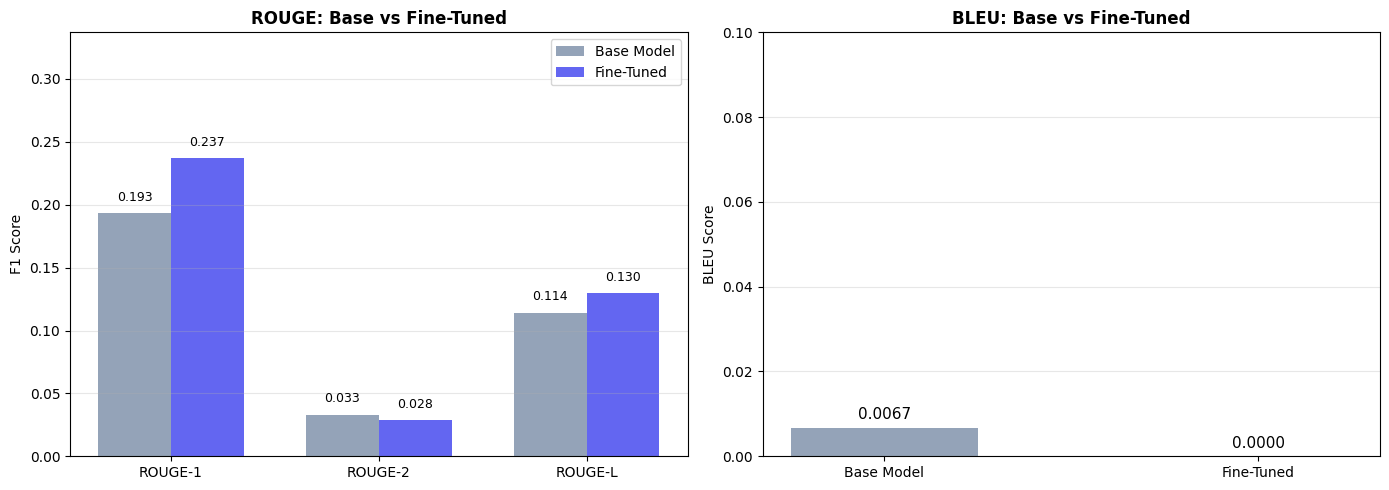

 Chart saved (improved scaling)


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── ROUGE ──
metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]

base_vals = [np.mean(base_rouge[k]) for k in ["rouge1", "rouge2", "rougeL"]]
ft_vals = [np.mean(ft_rouge[k]) for k in ["rouge1", "rouge2", "rougeL"]]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, base_vals, width, label="Base Model", color="#94a3b8")
bars2 = axes[0].bar(x + width/2, ft_vals, width, label="Fine-Tuned", color="#6366f1")

axes[0].set_ylabel("F1 Score")
axes[0].set_title("ROUGE: Base vs Fine-Tuned", fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim(0, max(max(base_vals), max(ft_vals)) + 0.1)
axes[0].grid(axis="y", alpha=0.3)

for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)

for bar in bars2:
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)

# ── BLEU ──
# FIX: avoid zero-scale problem
bleu_vals = [base_bleu_avg, ft_bleu_avg]

# if both very small, set minimum scale
y_max = max(bleu_vals)
if y_max < 0.05:
    y_max = 0.1   # force visibility

bars3 = axes[1].bar(
    ["Base Model", "Fine-Tuned"],
    bleu_vals,
    color=["#94a3b8", "#6366f1"],
    width=0.5
)

axes[1].set_ylabel("BLEU Score")
axes[1].set_title("BLEU: Base vs Fine-Tuned", fontweight="bold")
axes[1].set_ylim(0, y_max)
axes[1].grid(axis="y", alpha=0.3)

for bar in bars3:
    height = bar.get_height()
    axes[1].text(
        bar.get_x()+bar.get_width()/2.,
        height + 0.002,
        f'{height:.4f}',   # more precision for small values
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.savefig("/content/base_vs_finetuned.png", dpi=150, bbox_inches="tight")
plt.show()

print(" Chart saved (improved scaling)")

#ROUGE shows improvement, but BLEU is unreliable here due to low lexical overlap despite semantic similarity

In [40]:
print("=" * 80)
print(" SIDE-BY-SIDE COMPARISON")
print("=" * 80)
for i in range(min(5, len(eval_questions))):
    print(f"\n{'─'*80}\n❓ {eval_questions[i]}")
    print(f"\n Reference: {eval_references[i][:200]}...")
    print(f"\n Base: {base_responses[i][:200]}...")
    print(f"\n Fine-Tuned: {ft_responses[i][:200]}...")
    base_s = scorer.score(eval_references[i], base_responses[i])
    ft_s = scorer.score(eval_references[i], ft_responses[i])
    print(f"\n   ROUGE-L  Base: {base_s['rougeL'].fmeasure:.4f}  |  Fine-Tuned: {ft_s['rougeL'].fmeasure:.4f}")

 SIDE-BY-SIDE COMPARISON

────────────────────────────────────────────────────────────────────────────────
❓ Please describe the limitations of gpt-3?

 Reference: GPT-3 has several limitations: poor performance on natural language inference tasks, difficulty comparing two text snippets, inconsistent reasoning on complex tasks, potential for generating biased or...

 Base: GPT-3 is a large-scale transformer-based model that has been trained on vast amounts of text data from various sources to generate human-like responses for tasks such as translation, summarization, qu...

 Fine-Tuned: GPT-3 has some notable constraints:

1. **Limited Context**: GPT-3 can only generate text based on a limited context (up to 4096 tokens). Longer inputs result in truncated outputs.
2. **No In-context ...

   ROUGE-L  Base: 0.0940  |  Fine-Tuned: 0.1000

────────────────────────────────────────────────────────────────────────────────
❓ Please describe in-context learning?

 Reference: In-context learning

In [41]:
def ask_finetuned(question):
    prompt = f"### System:\n{SYSTEM_MSG}\n\n### User:\n{question}\n\n### Assistant:\n"
    output = ft_pipe(prompt, return_full_text=False)
    answer = output[0]["generated_text"].strip()
    print(f" {question}\n {answer}")
    return answer

ask_finetuned("What is the difference between LoRA and full fine-tuning?")
print()
ask_finetuned("Explain how RAG reduces hallucination in language models.")

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 What is the difference between LoRA and full fine-tuning?
 LoRA stands for "Low-Rank Adaptation" or "Linear Low Rank." It's a technique that reduces model size by using lower-rank matrices instead of dense weights during training. Full Fine-Tuning involves retraining all layers from scratch on new data to adapt your model parameters based on specific tasks. Both methods can be used together as part of larger strategies like LORA + FTT (Fine Tuning Technique).

 Explain how RAG reduces hallucination in language models.
 RAG (Revised Architecture for Generating Text) improves the quality of generated text by combining multiple sources to reduce errors or misinformation called "hallucinations". It does this through a multi-source approach that combines information from different domains like Wikipedia articles with more specific data such as training examples. This results in better overall accuracy compared to traditional approaches which often generate incorrect or misleading outputs d

'RAG (Revised Architecture for Generating Text) improves the quality of generated text by combining multiple sources to reduce errors or misinformation called "hallucinations". It does this through a multi-source approach that combines information from different domains like Wikipedia articles with more specific data such as training examples. This results in better overall accuracy compared to traditional approaches which often generate incorrect or misleading outputs due to biases present in their source datasets. The model uses attention mechanisms to focus on relevant parts of these diverse inputs while minimizing irrelevant elements leading to improved understanding and generation capabilities across various applications including translation tasks where it can produce coherent translations without introducing false facts into the output. Overall, RAG enhances generative performance significantly over existing methods especially when dealing with complex knowledge bases requiring 

In [42]:
eval_output = []
for i in range(len(eval_questions)):
    base_s = scorer.score(eval_references[i], base_responses[i])
    ft_s = scorer.score(eval_references[i], ft_responses[i])
    eval_output.append({"question": eval_questions[i], "reference": eval_references[i],
        "base_response": base_responses[i], "finetuned_response": ft_responses[i],
        "base_rouge1": round(base_s["rouge1"].fmeasure,4), "base_rougeL": round(base_s["rougeL"].fmeasure,4),
        "ft_rouge1": round(ft_s["rouge1"].fmeasure,4), "ft_rougeL": round(ft_s["rougeL"].fmeasure,4),
        "base_bleu": round(base_bleu[i],4), "ft_bleu": round(ft_bleu[i],4)})

pd.DataFrame(eval_output).to_csv("/content/evaluation_results.csv", index=False)
with open("/content/training_summary.txt", "w") as f:
    f.write(f"Model: {MODEL_ID}\nLoRA Rank: {lora_config.r}\nLoRA Alpha: {lora_config.lora_alpha}\n")
    f.write(f"Train: {len(train_dataset)}\nEval: {len(eval_dataset)}\nEpochs: {training_args.num_train_epochs}\n")
    f.write(f"LR: {training_args.learning_rate}\n\n"); f.write(metrics_df.to_string(index=False))

print(" All saved:")
print("   • /content/evaluation_results.csv\n   • /content/training_summary.txt")
print("   • /content/training_loss.png\n   • /content/base_vs_finetuned.png")
print("   • /content/finetuned_adapter/\n   • /content/dataset/")

 All saved:
   • /content/evaluation_results.csv
   • /content/training_summary.txt
   • /content/training_loss.png
   • /content/base_vs_finetuned.png
   • /content/finetuned_adapter/
   • /content/dataset/


In [43]:
import os
from google.colab import files

# Create a zip block combining all reports, charts, datasets, and the LoRA adapter
print(" Zipping Assignment 2 files...")

!zip -r assignment2_finetuning_results.zip \
  /content/evaluation_results.csv \
  /content/training_summary.txt \
  /content/training_loss.png \
  /content/base_vs_finetuned.png \
  /content/dataset \
  /content/finetuned_adapter

print(" Zip file created successfully!")

# Trigger the download to your PC
files.download("assignment2_finetuning_results.zip")

 Zipping Assignment 2 files...
  adding: content/evaluation_results.csv (deflated 66%)
  adding: content/training_summary.txt (deflated 35%)
  adding: content/training_loss.png (deflated 17%)
  adding: content/base_vs_finetuned.png (deflated 24%)
  adding: content/dataset/ (stored 0%)
  adding: content/dataset/train.csv (deflated 89%)
  adding: content/dataset/eval.json (deflated 85%)
  adding: content/dataset/train.json (deflated 90%)
  adding: content/dataset/eval.csv (deflated 84%)
  adding: content/finetuned_adapter/ (stored 0%)
  adding: content/finetuned_adapter/adapter_config.json (deflated 58%)
  adding: content/finetuned_adapter/README.md (deflated 65%)
  adding: content/finetuned_adapter/adapter_model.safetensors (deflated 22%)
  adding: content/finetuned_adapter/tokenizer.json (deflated 81%)
  adding: content/finetuned_adapter/chat_template.jinja (deflated 71%)
  adding: content/finetuned_adapter/tokenizer_config.json (deflated 60%)
 Zip file created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
import os
from google.colab import files

print(" Zipping Assignment 2 files (including intermediate checkpoints)...")

!zip -r assignment2_finetuning_results.zip \
  /content/evaluation_results.csv \
  /content/training_summary.txt \
  /content/training_loss.png \
  /content/base_vs_finetuned.png \
  /content/dataset \
  /content/finetuned_adapter \
  /content/finetuned_model

print(" Zip file created successfully!")

# Trigger the download to your PC
files.download("assignment2_finetuning_results.zip")

 Zipping Assignment 2 files (including intermediate checkpoints)...
updating: content/evaluation_results.csv (deflated 66%)
updating: content/training_summary.txt (deflated 35%)
updating: content/training_loss.png (deflated 17%)
updating: content/base_vs_finetuned.png (deflated 24%)
updating: content/dataset/ (stored 0%)
updating: content/dataset/train.csv (deflated 89%)
updating: content/dataset/eval.json (deflated 85%)
updating: content/dataset/train.json (deflated 90%)
updating: content/dataset/eval.csv (deflated 84%)
updating: content/finetuned_adapter/ (stored 0%)
updating: content/finetuned_adapter/adapter_config.json (deflated 58%)
updating: content/finetuned_adapter/README.md (deflated 65%)
updating: content/finetuned_adapter/adapter_model.safetensors (deflated 22%)
updating: content/finetuned_adapter/tokenizer.json (deflated 81%)
updating: content/finetuned_adapter/chat_template.jinja (deflated 71%)
updating: content/finetuned_adapter/tokenizer_config.json (deflated 60%)
  add

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>